# DETR Object Detection - Colab Optimized Training
## Assignment 2 - CO5085

**Model:** DETR (DEtection TRansformer) with ResNet-50

**Datasets:** COCO train2017 (full) + COCO val2017 (full)

**Environment:** Google Colab (GPU)

In [1]:
!pip install -q -U transformers pycocotools

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets

from transformers import DetrForObjectDetection
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

from tqdm import tqdm
import time
import urllib.request
import zipfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

IS_COLAB = 'google.colab' in sys.modules
IS_KAGGLE = os.path.exists('/kaggle')

print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Running on Colab: {IS_COLAB}')
print(f'Running on Kaggle: {IS_KAGGLE}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.5 MB/s eta 0:00:00
Device: cuda
PyTorch: 2.10.0+cu128
Running on Colab: True
Running on Kaggle: True


In [2]:
COCO_CLASSES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck',
    'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench',
    'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife',
    'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed',
    'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print(f'{len(COCO_CLASSES)} COCO classes')

# ===== Colab storage options =====
# If True, outputs/checkpoints are saved to Drive (persistent across sessions).
SAVE_TO_DRIVE = True
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/detr_full_training'

if IS_COLAB and SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = Path(DRIVE_PROJECT_DIR)
elif IS_COLAB:
    PROJECT_DIR = Path('/content/detr_full_training')
elif IS_KAGGLE:
    PROJECT_DIR = Path('/kaggle/working/detr_full_training')
else:
    PROJECT_DIR = Path.home() / '.cache' / 'detr_full_training'
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# If you already have COCO, set this to your dataset root and skip auto-detection/download.
# Expected structure under this folder:
#   train2017/ (optional in sanity mode)
#   val2017/
#   annotations/instances_train2017.json (optional in sanity mode)
#   annotations/instances_val2017.json
USER_DATA_DIR = ''
FORCE_DOWNLOAD = False
NEED_DOWNLOAD = False

def looks_like_coco_root(root: Path) -> bool:
    return (
        (root / 'val2017').exists() and
        (root / 'annotations').exists() and
        (root / 'annotations' / 'instances_val2017.json').exists()
    )

def auto_find_coco_in_colab() -> Path | None:
    candidates = [
        Path('/content/coco'),
        Path('/content/coco2017'),
        Path('/content/drive/MyDrive/coco'),
        Path('/content/drive/MyDrive/coco2017'),
        Path('/content/drive/MyDrive/datasets/coco'),
        Path('/content/drive/MyDrive/datasets/coco2017'),
    ]
    for cdir in candidates:
        if looks_like_coco_root(cdir):
            return cdir
    return None

def auto_find_coco_in_kaggle() -> Path | None:
    input_root = Path('/kaggle/input')
    if not input_root.exists():
        return None

    for top_dir in sorted(input_root.iterdir()):
        if not top_dir.is_dir():
            continue
        if looks_like_coco_root(top_dir):
            return top_dir
        for sub_dir in sorted(top_dir.iterdir()):
            if sub_dir.is_dir() and looks_like_coco_root(sub_dir):
                return sub_dir
    return None

user_data_dir = USER_DATA_DIR.strip()

if user_data_dir:
    DATA_DIR = Path(user_data_dir)
    if not DATA_DIR.exists():
        raise FileNotFoundError(f'USER_DATA_DIR does not exist: {DATA_DIR}')
    print(f'Using user dataset directory: {DATA_DIR}')
else:
    if IS_COLAB:
        DATA_DIR = auto_find_coco_in_colab()
        if DATA_DIR is None:
            DATA_DIR = Path('/content/coco')
            DATA_DIR.mkdir(parents=True, exist_ok=True)
            NEED_DOWNLOAD = True
            print(f'COCO not found in Colab paths. Will download to: {DATA_DIR}')
        else:
            print(f'Colab DATA_DIR (auto-detected): {DATA_DIR}')
    elif IS_KAGGLE:
        DATA_DIR = auto_find_coco_in_kaggle()
        if DATA_DIR is None:
            DATA_DIR = Path('/kaggle/working/coco')
            DATA_DIR.mkdir(parents=True, exist_ok=True)
            NEED_DOWNLOAD = True
            print(f'COCO not found in /kaggle/input. Will download to: {DATA_DIR}')
        else:
            print(f'Kaggle DATA_DIR (auto-detected): {DATA_DIR}')
    else:
        DATA_DIR = Path.home() / '.cache' / 'coco'
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        NEED_DOWNLOAD = True
        print(f'Local DATA_DIR: {DATA_DIR}')

if FORCE_DOWNLOAD:
    NEED_DOWNLOAD = True

# ===== SANITY CHECK MODE =====
# Bat True de test nhanh pipeline tren tap nho truoc khi chay full dataset.
PIPELINE_SANITY_CHECK = False
SANITY_TRAIN_SAMPLES = 512
SANITY_VAL_SAMPLES = 128
SANITY_EPOCHS = 5

IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS = 5 if (IS_COLAB or IS_KAGGLE) else 50
LEARNING_RATE = 1e-4
NUM_WORKERS = 2 if IS_COLAB else (2 if IS_KAGGLE else 4)
PIN_MEMORY = bool(torch.cuda.is_available())
PERSISTENT_WORKERS = (NUM_WORKERS > 0)

# In sanity mode, can use val2017 for both train/val to reduce storage/time.
SANITY_USE_VAL_AS_TRAIN = PIPELINE_SANITY_CHECK

if PIPELINE_SANITY_CHECK:
    EPOCHS = min(EPOCHS, SANITY_EPOCHS)

# Safety profile to reduce kernel crashes in Colab/Kaggle.
KERNEL_SAFE_MODE = True
if KERNEL_SAFE_MODE and (IS_COLAB or IS_KAGGLE):
    IMG_SIZE = min(IMG_SIZE, 512)
    BATCH_SIZE = min(BATCH_SIZE, 16)
    NUM_WORKERS = 2 if IS_COLAB else 0
    PERSISTENT_WORKERS = (NUM_WORKERS > 0)
    PIN_MEMORY = bool(torch.cuda.is_available())
    print('Kernel-safe mode enabled')

# Use gradient accumulation to keep effective batch while reducing peak memory.
GRADIENT_ACCUM_STEPS = 2 if KERNEL_SAFE_MODE and BATCH_SIZE <= 2 else 1

# Set False if you want to always train from scratch.
RESUME_FROM_CHECKPOINT = False

RUN_TAG = 'sanity' if PIPELINE_SANITY_CHECK else 'full'
PROJECT_DIR = PROJECT_DIR / RUN_TAG
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# COCO category IDs are sparse (not 1..80). Use explicit mapping for training labels.
COCO_CAT_IDS = [
    1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20,
    21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
    41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
    59, 60, 61, 62, 63, 64, 65, 67, 70, 72, 73, 74, 75, 76, 77, 78, 79,
    80, 81, 82, 84, 85, 86, 87, 88, 89, 90
]
CAT_ID_TO_LABEL = {cat_id: idx for idx, cat_id in enumerate(COCO_CAT_IDS)}
LABEL_TO_CAT_ID = {idx: cat_id for cat_id, idx in CAT_ID_TO_LABEL.items()}

print(f'Run mode: {RUN_TAG}')
print(f'Output dir: {PROJECT_DIR}')
print(f'Data dir: {DATA_DIR}')
print(f'Image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')
print(f'Workers: {NUM_WORKERS}, pin_memory={PIN_MEMORY}, persistent_workers={PERSISTENT_WORKERS}')
print(f'Gradient accumulation: {GRADIENT_ACCUM_STEPS}')
print(f'Resume from checkpoint: {RESUME_FROM_CHECKPOINT}')
if PIPELINE_SANITY_CHECK:
    print(f'Sanity subset: train={SANITY_TRAIN_SAMPLES}, val={SANITY_VAL_SAMPLES}')
    print(f'Sanity uses val2017 as source: {SANITY_USE_VAL_AS_TRAIN}')
print(f'Need download: {NEED_DOWNLOAD}')
print(f'Category mapping size: {len(CAT_ID_TO_LABEL)}')

78 COCO classes
Mounted at /content/drive
COCO not found in Colab paths. Will download to: /content/coco
Kernel-safe mode enabled
Run mode: full
Output dir: /content/drive/MyDrive/detr_full_training/full
Data dir: /content/coco
Image size: 512x512
Batch size: 16
Epochs: 5
Workers: 2, pin_memory=True, persistent_workers=True
Gradient accumulation: 1
Resume from checkpoint: False
Need download: True
Category mapping size: 80


In [3]:
if not NEED_DOWNLOAD:
    print('COCO already available. Skip download.')

    required = [
        DATA_DIR / 'val2017',
        DATA_DIR / 'annotations' / 'instances_val2017.json',
    ]
    if not SANITY_USE_VAL_AS_TRAIN:
        required.extend([
            DATA_DIR / 'train2017',
            DATA_DIR / 'annotations' / 'instances_train2017.json',
        ])

    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError('Dataset path is set but missing files:\n' + '\n'.join(missing))
else:
    # Recreate output dir in case user cleaned /kaggle/working between cells.
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print(f'\nDownloading COCO datasets to: {DATA_DIR}')

    def download_file(url, dest_path, desc=''):
        dest_path = Path(dest_path)
        dest_path.parent.mkdir(parents=True, exist_ok=True)

        if dest_path.exists():
            print(f'Already exists: {dest_path.name}')
            return True

        print(f'Downloading {desc}...')
        try:
            urllib.request.urlretrieve(url, str(dest_path))
            size = dest_path.stat().st_size / (1024**3)
            print(f'   {size:.2f} GB')
            return True
        except Exception as e:
            print(f'Error: {e}')
            return False

    ann_zip = DATA_DIR / 'annotations_trainval2017.zip'
    train_zip = DATA_DIR / 'train2017.zip'
    val_zip = DATA_DIR / 'val2017.zip'

    ok_ann = download_file(
        'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
        ann_zip,
        'Annotations (~250MB)'
    )

    # In sanity mode, skip train2017 to avoid Kaggle disk overflow.
    if SANITY_USE_VAL_AS_TRAIN:
        ok_train = True
        print('Skip train2017 download in sanity mode (using val2017 for pipeline test).')
    else:
        ok_train = download_file(
            'http://images.cocodataset.org/zips/train2017.zip',
            train_zip,
            'train2017 (~18GB)'
        )

    ok_val = download_file(
        'http://images.cocodataset.org/zips/val2017.zip',
        val_zip,
        'val2017 (~1GB)'
    )

    def extract_zip(zip_path):
        zip_path = Path(zip_path)
        if not zip_path.exists():
            return
        print(f'Extracting {zip_path.name}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        zip_path.unlink()

    zip_list = [ann_zip, val_zip]
    if not SANITY_USE_VAL_AS_TRAIN:
        zip_list.append(train_zip)

    for z in zip_list:
        if z.exists():
            extract_zip(z)

    if ok_ann and ok_train and ok_val:
        print('Datasets ready!')
    else:
        raise RuntimeError('Download failed for one or more COCO files.')


   0.24 GB
   18.01 GB
   0.76 GB
Extracting annotations_trainval2017.zip...
Extracting val2017.zip...
Extracting train2017.zip...
Datasets ready!


In [4]:
from torch.utils.data import Subset

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def collate_fn(batch, is_train=False):
    images, annos_list, sizes, image_ids = [], [], [], []
    transforms_fn = train_transforms if is_train else val_transforms

    for img_pil, annos in batch:
        w, h = img_pil.size
        sizes.append((h, w))
        images.append(transforms_fn(img_pil))

        # Keep original COCO image_id for correct COCOeval alignment.
        if len(annos) > 0 and 'image_id' in annos[0]:
            image_ids.append(int(annos[0]['image_id']))
        else:
            image_ids.append(-1)

        norm_annos = []
        for anno in annos:
            x, y, aw, ah = anno['bbox']
            cx = (x + aw / 2) / w
            cy = (y + ah / 2) / h
            cw, ch = aw / w, ah / h
            cx = max(0, min(1, cx))
            cy = max(0, min(1, cy))
            cw = max(0, min(1, cw))
            ch = max(0, min(1, ch))
            norm_annos.append({
                'bbox': [cx, cy, cw, ch],
                'category_id': anno['category_id'],
                'area': anno.get('area', aw * ah),
                'iscrowd': anno.get('iscrowd', 0),
                'image_id': int(anno.get('image_id', -1))
            })
        annos_list.append(norm_annos)

    return {
        'pixel_values': torch.stack(images),
        'annotations': annos_list,
        'orig_sizes': sizes,
        'image_ids': image_ids
    }

print('Creating datasets...')

if SANITY_USE_VAL_AS_TRAIN:
    # Disk-safe sanity mode: use val2017 as source and split into train/val subsets.
    base_dataset = datasets.CocoDetection(
        str(DATA_DIR / 'val2017'),
        str(DATA_DIR / 'annotations' / 'instances_val2017.json'),
        transforms=None
    )

    rng = np.random.default_rng(42)
    perm = rng.permutation(len(base_dataset)).tolist()

    train_size = min(SANITY_TRAIN_SAMPLES, len(base_dataset))
    val_size = min(SANITY_VAL_SAMPLES, max(0, len(base_dataset) - train_size))

    train_indices = perm[:train_size]
    val_indices = perm[train_size:train_size + val_size]

    train_dataset = Subset(base_dataset, train_indices)
    val_dataset = Subset(base_dataset, val_indices)
    print(f'Using val2017 split for sanity: train={len(train_dataset)}, val={len(val_dataset)}')
else:
    train_dataset = datasets.CocoDetection(
        str(DATA_DIR / 'train2017'),
        str(DATA_DIR / 'annotations' / 'instances_train2017.json'),
        transforms=None
    )
    val_dataset = datasets.CocoDetection(
        str(DATA_DIR / 'val2017'),
        str(DATA_DIR / 'annotations' / 'instances_val2017.json'),
        transforms=None
    )

    if PIPELINE_SANITY_CHECK:
        rng = np.random.default_rng(42)
        train_size = min(SANITY_TRAIN_SAMPLES, len(train_dataset))
        val_size = min(SANITY_VAL_SAMPLES, len(val_dataset))

        train_indices = rng.choice(len(train_dataset), size=train_size, replace=False).tolist()
        val_indices = rng.choice(len(val_dataset), size=val_size, replace=False).tolist()

        train_dataset = Subset(train_dataset, train_indices)
        val_dataset = Subset(val_dataset, val_indices)
        print(f'Using sanity subset: train={len(train_dataset)}, val={len(val_dataset)}')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    collate_fn=lambda b: collate_fn(b, True),
    drop_last=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    collate_fn=lambda b: collate_fn(b, False)
)

print(f'Train: {len(train_dataset)} images ({len(train_loader)} batches)')
print(f'Val: {len(val_dataset)} images ({len(val_loader)} batches)')

Creating datasets...
loading annotations into memory...
Done (t=12.72s)
creating index...
index created!
loading annotations into memory...
Done (t=0.57s)
creating index...
index created!
Train: 118287 images (7392 batches)
Val: 5000 images (313 batches)


In [5]:
print('Loading DETR pretrained model...')

# Keep original pretrained head for COCO for much better starting point.
model = DetrForObjectDetection.from_pretrained('facebook/detr-resnet-50')
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Build robust mapping from model label index -> COCO category id via class names.
COCO_NAME_TO_CAT_ID = {name: cat_id for name, cat_id in zip(COCO_CLASSES, COCO_CAT_IDS)}
MODEL_LABEL_TO_CAT_ID = {}
CAT_ID_TO_MODEL_LABEL = {}

for label_idx, label_name in model.config.id2label.items():
    norm_name = str(label_name).strip().lower()
    if norm_name in COCO_NAME_TO_CAT_ID:
        cat_id = COCO_NAME_TO_CAT_ID[norm_name]
        MODEL_LABEL_TO_CAT_ID[int(label_idx)] = int(cat_id)
        CAT_ID_TO_MODEL_LABEL[int(cat_id)] = int(label_idx)

print('Model loaded')
print(f'  Total params: {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')
print(f'  Mapped labels: {len(MODEL_LABEL_TO_CAT_ID)} / {len(model.config.id2label)}')

Loading DETR pretrained model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
  Total params: 41,524,768
  Trainable params: 41,524,768
  Mapped labels: 78 / 91


In [6]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LEARNING_RATE * 0.01)

# Mixed precision helps Kaggle GPUs run faster and use less memory.
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

checkpoint_dir = PROJECT_DIR / 'checkpoints'
checkpoint_dir.mkdir(parents=True, exist_ok=True)
last_ckpt_path = checkpoint_dir / 'last.pt'

history = {'epoch': [], 'train_loss': [], 'val_loss': []}
start_epoch = 0
best_val_loss = float('inf')

if RESUME_FROM_CHECKPOINT and last_ckpt_path.exists():
    print(f'Loading checkpoint: {last_ckpt_path}')
    ckpt = torch.load(last_ckpt_path, map_location=device)

    model.load_state_dict(ckpt['model_state_dict'])
    if 'optimizer_state_dict' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    if 'scaler_state_dict' in ckpt and use_amp:
        scaler.load_state_dict(ckpt['scaler_state_dict'])

    history = ckpt.get('history', history)
    start_epoch = int(ckpt.get('epoch', -1)) + 1

    if len(history.get('val_loss', [])) > 0:
        best_val_loss = min(history['val_loss'])

    print(f'Resumed from epoch {start_epoch}')
elif RESUME_FROM_CHECKPOINT:
    print('RESUME_FROM_CHECKPOINT=True but no checkpoint found. Training from scratch.')
else:
    print('Resume disabled. Training from scratch.')

print(f'Optimizer: AdamW (lr={LEARNING_RATE})')
print('Scheduler: Cosine Annealing')
print(f'AMP enabled: {use_amp}')
print(f'Checkpoints: {checkpoint_dir}')

Resume disabled. Training from scratch.
Optimizer: AdamW (lr=0.0001)
Scheduler: Cosine Annealing
AMP enabled: True
Checkpoints: /content/drive/MyDrive/detr_full_training/full/checkpoints


In [7]:
def build_targets(annos_list):
    """Convert COCO category IDs to the pretrained DETR label space."""
    targets = []
    for annos in annos_list:
        boxes, labels = [], []
        for anno in annos:
            if anno.get('iscrowd', 0) or anno.get('area', 0) <= 0:
                continue

            cx, cy, cw, ch = anno['bbox']
            if cw <= 0 or ch <= 0:
                continue

            cat_id = int(anno['category_id'])
            if cat_id not in CAT_ID_TO_MODEL_LABEL:
                continue

            boxes.append([cx, cy, cw, ch])
            labels.append(CAT_ID_TO_MODEL_LABEL[cat_id])

        if len(boxes) > 0:
            targets.append({
                'boxes': torch.tensor(boxes, dtype=torch.float32).to(device),
                'class_labels': torch.tensor(labels, dtype=torch.long).to(device)
            })
        else:
            targets.append({
                'boxes': torch.zeros((0, 4), dtype=torch.float32).to(device),
                'class_labels': torch.zeros(0, dtype=torch.long).to(device)
            })
    return targets


def train_epoch(epoch):
    model.train()
    total_loss = 0.0
    valid_steps = 0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')

    optimizer.zero_grad(set_to_none=True)
    for step_idx, batch in enumerate(pbar, start=1):
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        annos_list = batch['annotations']
        targets = build_targets(annos_list)

        try:
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(pixel_values=pixel_values, labels=targets)
                raw_loss = outputs.loss

            if torch.isnan(raw_loss) or torch.isinf(raw_loss):
                optimizer.zero_grad(set_to_none=True)
                continue

            loss = raw_loss / GRADIENT_ACCUM_STEPS
            scaler.scale(loss).backward()

            if step_idx % GRADIENT_ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            total_loss += raw_loss.item()
            valid_steps += 1
            pbar.set_postfix({'loss': f'{raw_loss.item():.4f}'})

        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                optimizer.zero_grad(set_to_none=True)
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                continue
            raise
        except Exception:
            optimizer.zero_grad(set_to_none=True)
            continue

    # Flush leftover gradients when number of steps is not divisible by accumulation.
    if valid_steps > 0 and (valid_steps % GRADIENT_ACCUM_STEPS) != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    return total_loss / max(valid_steps, 1)


def validate(epoch):
    model.eval()
    total_loss = 0.0
    valid_steps = 0
    pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')

    with torch.no_grad():
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device, non_blocking=True)
            annos_list = batch['annotations']
            targets = build_targets(annos_list)

            try:
                with torch.cuda.amp.autocast(enabled=use_amp):
                    outputs = model(pixel_values=pixel_values, labels=targets)
                    loss = outputs.loss

                if torch.isnan(loss) or torch.isinf(loss):
                    continue

                total_loss += loss.item()
                valid_steps += 1
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            except RuntimeError as e:
                if 'out of memory' in str(e).lower():
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    continue
                raise
            except Exception:
                continue

    return total_loss / max(valid_steps, 1)

In [8]:
print('\nStarting training...')

if start_epoch >= EPOCHS:
    print(f'Model already trained to epoch {start_epoch}/{EPOCHS}. Increase EPOCHS to continue.')
else:
    try:
        for epoch in range(start_epoch, EPOCHS):
            train_loss = train_epoch(epoch)
            val_loss = validate(epoch)
            scheduler.step()

            history['epoch'].append(epoch + 1)
            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)

            print(f'\nEpoch {epoch+1}/{EPOCHS}: Train={train_loss:.4f}, Val={val_loss:.4f}')

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'scaler_state_dict': scaler.state_dict() if use_amp else None,
                'history': history,
                'best_val_loss': best_val_loss,
                'cat_id_to_label': CAT_ID_TO_LABEL,
                'label_to_cat_id': LABEL_TO_CAT_ID
            }
            torch.save(checkpoint, checkpoint_dir / 'last.pt')

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                checkpoint['best_val_loss'] = best_val_loss
                torch.save(checkpoint, checkpoint_dir / 'best.pt')
                print(f'   Saved best (val_loss={val_loss:.4f})')

    except KeyboardInterrupt:
        print('\nTraining interrupted')
    except Exception as e:
        print(f'\nError: {e}')
        import traceback
        traceback.print_exc()

print('\nTraining done!')


Starting training...


Epoch 1/5 [Val]: 100%|██████████| 313/313 [00:36<00:00,  8.55it/s, loss=2.4320]



Epoch 1/5: Train=3.3484, Val=3.0047
   Saved best (val_loss=3.0047)


Epoch 2/5 [Val]: 100%|██████████| 313/313 [00:36<00:00,  8.58it/s, loss=2.5520]



Epoch 2/5: Train=3.0647, Val=2.8331
   Saved best (val_loss=2.8331)


...


Epoch 3/5: Train=2.7979, Val=2.6874
   Saved best (val_loss=2.6874)


Epoch 4/5 [Val]: 100%|██████████| 313/313 [00:36<00:00,  8.58it/s, loss=2.0106]



Epoch 4/5: Train=2.5742, Val=2.4359
   Saved best (val_loss=2.4359)


Epoch 5/5 [Val]: 100%|██████████| 313/313 [00:36<00:00,  8.57it/s, loss=1.8126]



Epoch 5/5: Train=2.3798, Val=2.2629
   Saved best (val_loss=2.2629)

Training done!


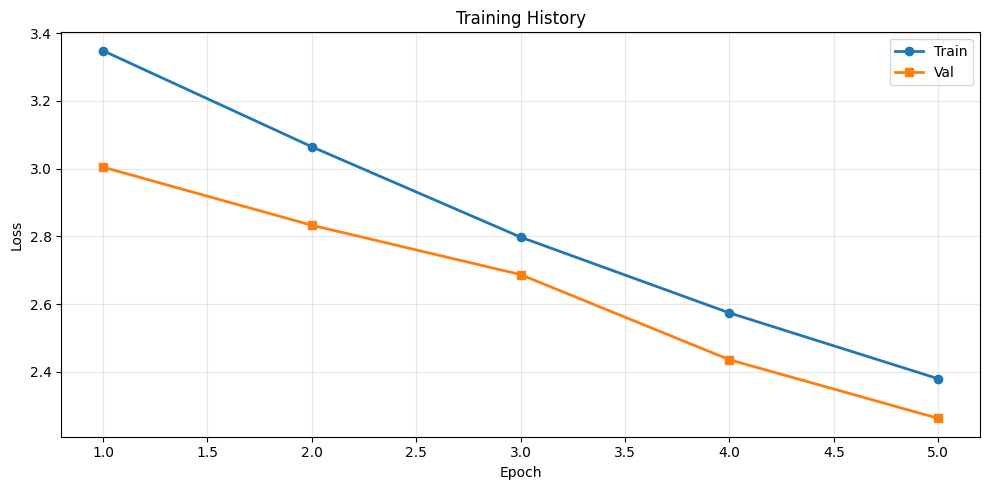

✓ Saved to /content/drive/MyDrive/detr_full_training/full


In [9]:
if len(history['epoch']) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history['epoch'], history['train_loss'], 'o-', label='Train', linewidth=2)
    ax.plot(history['epoch'], history['val_loss'], 's-', label='Val', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training History')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / 'training_history.png', dpi=100)
    plt.show()

    df = pd.DataFrame(history)
    df.to_csv(PROJECT_DIR / 'training_history.csv', index=False)
    print(f'✓ Saved to {PROJECT_DIR}')
else:
    print('No training history')


## 11. Compute Metrics (mAP, Precision, Recall, F1)



In [10]:
def compute_metrics(conf_threshold=0.2):
    """Compute mAP with COCO API and speed metrics."""
    print(f"\n{'='*70}")
    print(f"COMPUTING METRICS (conf_threshold={conf_threshold})")
    print(f"{'='*70}")

    model.eval()
    predictions = []
    inference_times = []

    coco_val = COCO(str(DATA_DIR / 'annotations' / 'instances_val2017.json'))
    coco_image_ids = set(coco_val.imgs.keys())

    print(f"\nRunning inference on {len(val_dataset)} validation images...")

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Computing metrics")
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            orig_sizes = batch['orig_sizes']
            batch_image_ids = batch.get('image_ids', [-1] * len(orig_sizes))

            start_time = time.time()
            outputs = model(pixel_values=pixel_values)
            inference_times.append(time.time() - start_time)

            logits = outputs.logits
            pred_boxes = outputs.pred_boxes

            for img_idx_in_batch, orig_size in enumerate(orig_sizes):
                orig_h, orig_w = orig_size
                image_id = int(batch_image_ids[img_idx_in_batch])

                logits_i = logits[img_idx_in_batch]
                boxes_i = pred_boxes[img_idx_in_batch]

                # Exclude the final no-object class before selecting predictions.
                probs = torch.softmax(logits_i, dim=-1)[:, :-1]
                scores, labels = torch.max(probs, dim=-1)

                keep = scores > conf_threshold

                for pred_box, score, label in zip(boxes_i[keep], scores[keep], labels[keep]):
                    cx, cy, w, h = pred_box.cpu().numpy()

                    x = (cx - w / 2) * orig_w
                    y = (cy - h / 2) * orig_h
                    w_pixel = w * orig_w
                    h_pixel = h * orig_h

                    x = max(0, x)
                    y = max(0, y)
                    w_pixel = min(w_pixel, orig_w - x)
                    h_pixel = min(h_pixel, orig_h - y)

                    if w_pixel < 1 or h_pixel < 1:
                        continue

                    label_idx = int(label)
                    if label_idx not in MODEL_LABEL_TO_CAT_ID:
                        continue
                    category_id = MODEL_LABEL_TO_CAT_ID[label_idx]

                    if image_id in coco_image_ids:
                        predictions.append({
                            'image_id': image_id,
                            'category_id': category_id,
                            'bbox': [float(x), float(y), float(w_pixel), float(h_pixel)],
                            'score': float(score.cpu().numpy())
                        })

    metrics = {}

    if len(inference_times) > 0:
        total_inference_time = sum(inference_times)
        total_images = len(val_dataset)
        fps = total_images / total_inference_time if total_inference_time > 0 else 0
        metrics['fps'] = fps
        metrics['avg_inference_time_ms'] = (total_inference_time / total_images) * 1000

    print(f"\nPrediction Summary:")
    print(f"   Total predictions: {len(predictions)}")
    print(f"   Confidence threshold: {conf_threshold}")

    try:
        if len(predictions) > 0:
            print("\nEvaluating with COCO API...")
            coco_dt = coco_val.loadRes(predictions)
            coco_eval = COCOeval(coco_val, coco_dt, "bbox")
            coco_eval.evaluate()
            coco_eval.accumulate()
            coco_eval.summarize()

            metrics['mAP@0.5:0.95'] = float(coco_eval.stats[0])
            metrics['mAP@0.5'] = float(coco_eval.stats[1])
            metrics['mAP@0.75'] = float(coco_eval.stats[2])
            metrics['mAP_small'] = float(coco_eval.stats[3])
            metrics['mAP_medium'] = float(coco_eval.stats[4])
            metrics['mAP_large'] = float(coco_eval.stats[5])
            metrics['AR@1'] = float(coco_eval.stats[6])
            metrics['AR@10'] = float(coco_eval.stats[7])
            metrics['AR@100'] = float(coco_eval.stats[8])
        else:
            print('No predictions generated!')
            metrics['mAP@0.5:0.95'] = 0
            metrics['mAP@0.5'] = 0
            metrics['mAP@0.75'] = 0
    except Exception as e:
        print(f"mAP computation error: {e}")
        metrics['mAP@0.5:0.95'] = 0
        metrics['mAP@0.5'] = 0
        metrics['mAP@0.75'] = 0

    return metrics, predictions


# Run metrics computation
try:
    metrics, val_predictions = compute_metrics(conf_threshold=0.2)
    print(f"\n{'='*70}")
    print('EVALUATION RESULTS')
    print(f"{'='*70}")

    if metrics:
        print(f"\nDetection Metrics (mAP):")
        print(f"  mAP@0.5:0.95:   {metrics.get('mAP@0.5:0.95', 0):.4f}")
        print(f"  mAP@0.5:        {metrics.get('mAP@0.5', 0):.4f}")
        print(f"  mAP@0.75:       {metrics.get('mAP@0.75', 0):.4f}")

        print(f"\nObject Size Metrics:")
        print(f"  Small objects:  {metrics.get('mAP_small', 0):.4f}")
        print(f"  Medium objects: {metrics.get('mAP_medium', 0):.4f}")
        print(f"  Large objects:  {metrics.get('mAP_large', 0):.4f}")

        print(f"\nSpeed Metrics:")
        print(f"  FPS:            {metrics.get('fps', 0):.2f} frames/second")
        print(f"  Inference time: {metrics.get('avg_inference_time_ms', 0):.2f} ms/image")

        with open(PROJECT_DIR / 'metrics.json', 'w') as f:
            json.dump(metrics, f, indent=2)
        print(f"\nMetrics saved to {PROJECT_DIR / 'metrics.json'}")
except Exception as e:
    print(f"Error during metrics computation: {e}")
    import traceback
    traceback.print_exc()


COMPUTING METRICS (conf_threshold=0.2)
loading annotations into memory...
Done (t=0.52s)
creating index...
index created!

Running inference on 5000 validation images...


Computing metrics: 100%|██████████| 313/313 [00:37<00:00,  8.41it/s]



Prediction Summary:
   Total predictions: 181434
   Confidence threshold: 0.2

Evaluating with COCO API...
Loading and preparing results...
DONE (t=2.89s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=28.44s).
Accumulating evaluation results...
DONE (t=3.84s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.122
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.219
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.031
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.119
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.199
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.151
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.233
 Average Recall     (AR) @[ IoU=0.50:0.


## 12. Inference & Visualization




Visualizing predictions on validation set...


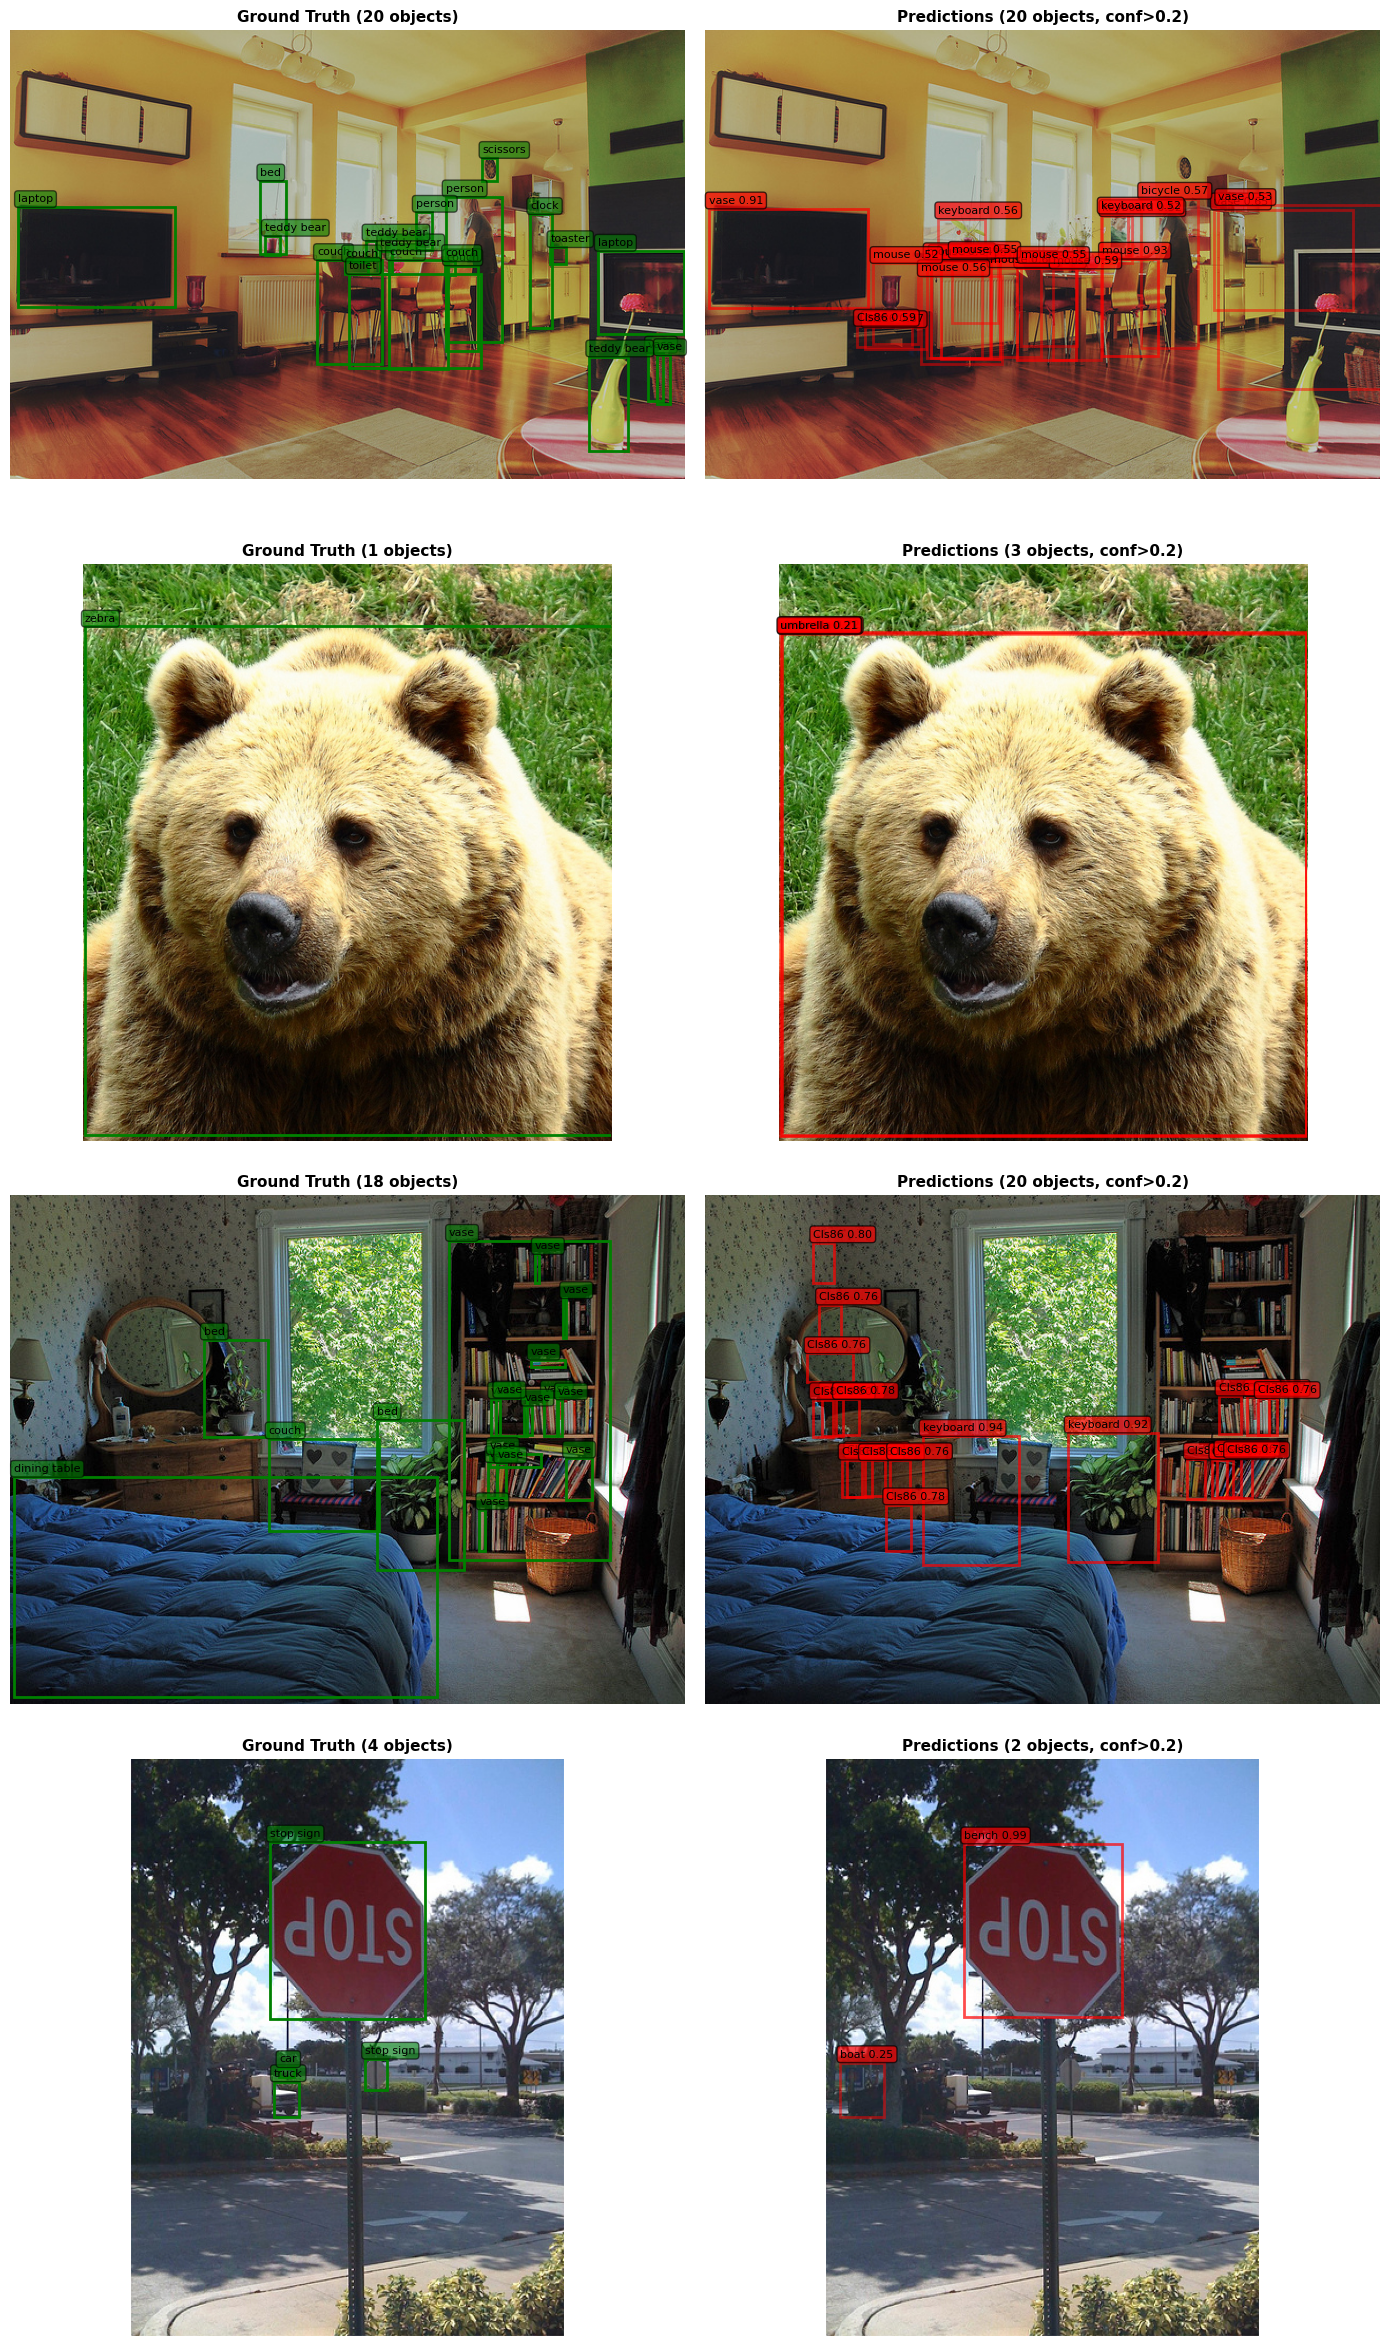

Saved: /content/drive/MyDrive/detr_full_training/full/inference_results.png
Visualization complete


In [11]:
def visualize_predictions(num_images=4, conf_threshold=0.2):
    """Visualize model predictions on validation set"""
    model.eval()

    fig, axes = plt.subplots(num_images, 2, figsize=(14, 6*num_images))
    if num_images == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for idx in range(min(num_images, len(val_dataset))):
            image_pil, annos = val_dataset[idx]
            image_np = np.array(image_pil)
            h_orig, w_orig = image_np.shape[:2]

            # Prepare input
            image_resized = val_transforms(image_pil).unsqueeze(0).to(device)

            # Ground truth
            ax = axes[idx, 0]
            ax.imshow(image_np)
            gt_count = 0
            for anno in annos:
                x, y, aw, ah = anno['bbox']
                cat_id = int(anno['category_id'])
                label_idx = CAT_ID_TO_LABEL.get(cat_id, None)
                class_name = COCO_CLASSES[label_idx] if label_idx is not None and label_idx < len(COCO_CLASSES) else 'Unknown'

                rect = plt.Rectangle((x, y), aw, ah, linewidth=2, edgecolor='green', facecolor='none')
                ax.add_patch(rect)
                ax.text(x, max(10, y-5), class_name, fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='green', alpha=0.6))
                gt_count += 1

            ax.set_title(f'Ground Truth ({gt_count} objects)', fontsize=11, fontweight='bold')
            ax.axis('off')

            # Predictions
            ax = axes[idx, 1]
            ax.imshow(image_np)

            outputs = model(pixel_values=image_resized)
            logits = outputs.logits[0]
            boxes = outputs.pred_boxes[0]

            # Exclude no-object class before argmax.
            probs = torch.softmax(logits, dim=-1)[:, :-1]
            scores, labels = torch.max(probs, dim=-1)

            keep = scores > conf_threshold

            pred_count = 0
            if keep.sum() > 0:
                # Get top predictions
                top_k = 20
                top_indices = torch.topk(scores[keep], k=min(top_k, int(keep.sum().item())), largest=True).indices
                filtered_boxes = boxes[keep][top_indices]
                filtered_scores = scores[keep][top_indices]
                filtered_labels = labels[keep][top_indices]

                for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
                    label_idx = int(label)
                    class_name = COCO_CLASSES[label_idx] if label_idx < len(COCO_CLASSES) else f'Cls{label_idx}'

                    # Convert from normalized [cx, cy, w, h] to pixel coords
                    cx, cy, cw, ch = box.cpu().numpy()
                    x1 = max(0, (cx - cw/2) * w_orig)
                    y1 = max(0, (cy - ch/2) * h_orig)
                    w_pix = cw * w_orig
                    h_pix = ch * h_orig

                    if w_pix > 3 and h_pix > 3:
                        rect = plt.Rectangle((x1, y1), w_pix, h_pix, linewidth=2,
                                           edgecolor='red', facecolor='none',
                                           alpha=0.7 if score > 0.7 else 0.5)
                        ax.add_patch(rect)
                        ax.text(x1, max(10, y1-5), f'{class_name} {score:.2f}', fontsize=8,
                               bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))
                        pred_count += 1

            ax.set_title(f'Predictions ({pred_count} objects, conf>{conf_threshold})', fontsize=11, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(PROJECT_DIR / 'inference_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved: {PROJECT_DIR / 'inference_results.png'}")

# Run visualization
print("\nVisualizing predictions on validation set...")
try:
    visualize_predictions(num_images=4, conf_threshold=0.2)
    print("Visualization complete")
except Exception as e:
    print(f"Could not visualize: {e}")
    import traceback
    traceback.print_exc()



## 13. Metrics Visualization & Summary



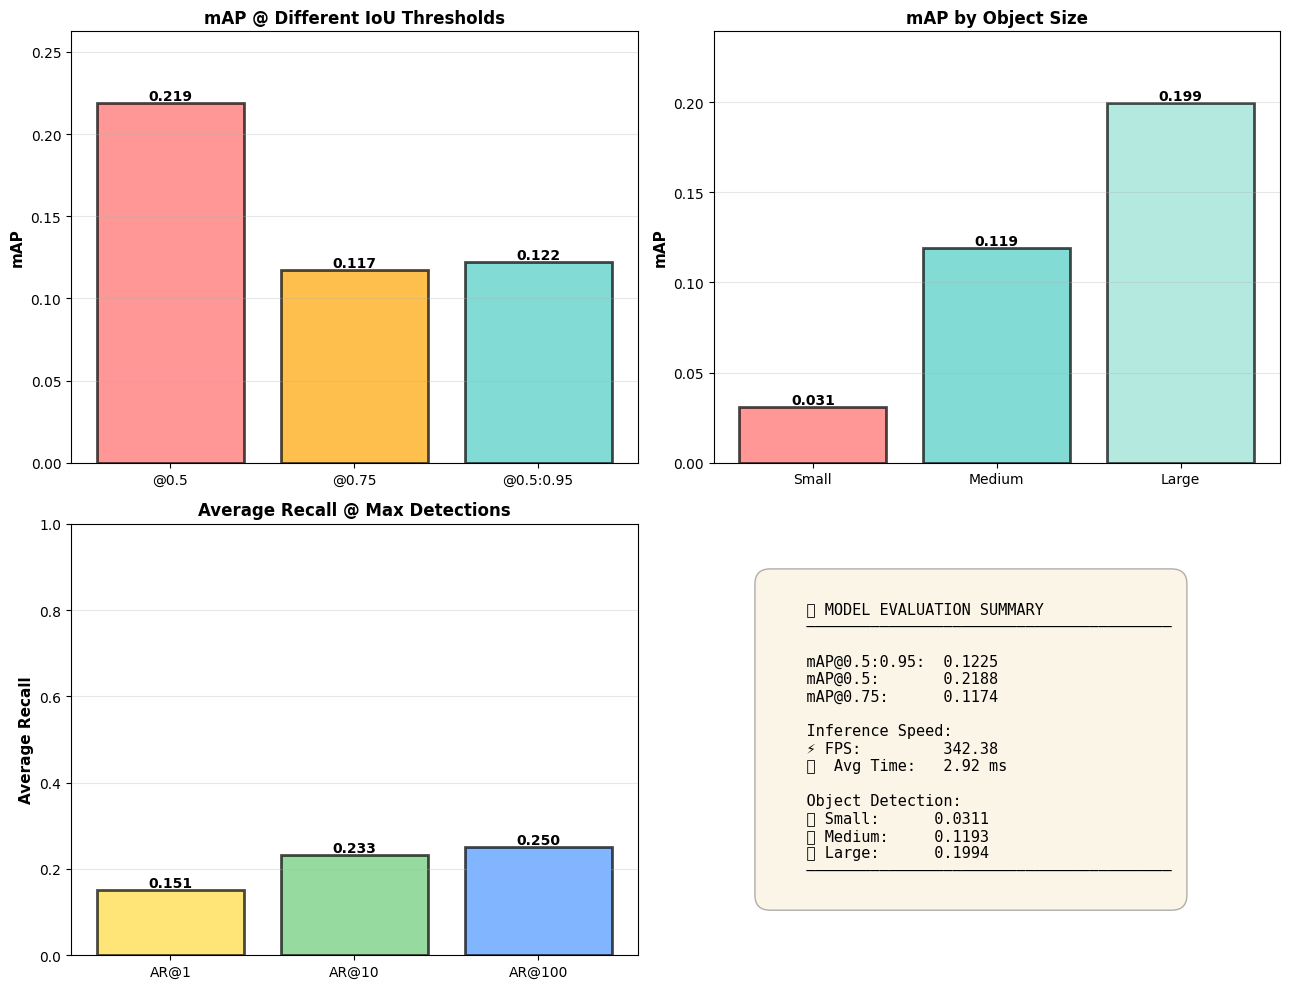

✓ Saved: /content/drive/MyDrive/detr_full_training/full/metrics_visualization.png

🎉 TRAINING & EVALUATION COMPLETE!

📁 Output Files (/content/drive/MyDrive/detr_full_training/full):
  ✓ training_history.png           (42.9 KB ) - Training loss curves
  ✓ training_history.csv           (0.2 KB  ) - Training history (CSV)
  ✓ inference_results.png          (2.7 MB  ) - Inference visualization
  ✓ metrics_visualization.png      (83.6 KB ) - Metrics charts
  ✓ metrics.json                   (0.4 KB  ) - Metrics (JSON)
  ✓ checkpoints/best.pt            (476.0 MB) - Best model checkpoint
  ✓ checkpoints/last.pt            (476.0 MB) - Last model checkpoint

✅ All done! Ready to deploy or further train.


In [12]:
# Visualize metrics
if 'metrics' in locals() and isinstance(metrics, dict):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    # mAP across IoU thresholds
    ax = axes[0, 0]
    iou_thresholds = ['@0.5', '@0.75', '@0.5:0.95']
    iou_values = [
        metrics.get('mAP@0.5', 0),
        metrics.get('mAP@0.75', 0),
        metrics.get('mAP@0.5:0.95', 0)
    ]
    colors = ['#FF6B6B', '#FFA500', '#4ECDC4']
    bars = ax.bar(iou_thresholds, iou_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('mAP', fontsize=11, fontweight='bold')
    ax.set_title('mAP @ Different IoU Thresholds', fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(iou_values) * 1.2 if max(iou_values) > 0 else 1])
    for bar, val in zip(bars, iou_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # mAP by object size
    ax = axes[0, 1]
    sizes = ['Small', 'Medium', 'Large']
    size_values = [
        metrics.get('mAP_small', 0),
        metrics.get('mAP_medium', 0),
        metrics.get('mAP_large', 0)
    ]
    colors_size = ['#FF6B6B', '#4ECDC4', '#95E1D3']
    bars = ax.bar(sizes, size_values, color=colors_size, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('mAP', fontsize=11, fontweight='bold')
    ax.set_title('mAP by Object Size', fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(size_values) * 1.2 if max(size_values) > 0 else 1])
    for bar, val in zip(bars, size_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Recall at different max detections
    ax = axes[1, 0]
    ar_metrics = ['AR@1', 'AR@10', 'AR@100']
    ar_values = [
        metrics.get('AR@1', 0),
        metrics.get('AR@10', 0),
        metrics.get('AR@100', 0)
    ]
    colors_ar = ['#FFD93D', '#6BCB77', '#4D96FF']
    bars = ax.bar(ar_metrics, ar_values, color=colors_ar, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_ylabel('Average Recall', fontsize=11, fontweight='bold')
    ax.set_title('Average Recall @ Max Detections', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    for bar, val in zip(bars, ar_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Summary text
    ax = axes[1, 1]
    ax.axis('off')
    summary_text = f"""
    📊 MODEL EVALUATION SUMMARY
    {'─'*40}

    mAP@0.5:0.95:  {metrics.get('mAP@0.5:0.95', 0):.4f}
    mAP@0.5:       {metrics.get('mAP@0.5', 0):.4f}
    mAP@0.75:      {metrics.get('mAP@0.75', 0):.4f}

    Inference Speed:
    ⚡ FPS:         {metrics.get('fps', 0):.2f}
    ⏱  Avg Time:   {metrics.get('avg_inference_time_ms', 0):.2f} ms

    Object Detection:
    🎯 Small:      {metrics.get('mAP_small', 0):.4f}
    🎯 Medium:     {metrics.get('mAP_medium', 0):.4f}
    🎯 Large:      {metrics.get('mAP_large', 0):.4f}
    {'─'*40}
    """
    ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
           verticalalignment='center', bbox=dict(boxstyle='round',
           facecolor='wheat', alpha=0.3, pad=1))

    plt.tight_layout()
    plt.savefig(PROJECT_DIR / 'metrics_visualization.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {PROJECT_DIR / 'metrics_visualization.png'}")
else:
    print("⚠ No metrics available. Run metrics computation first.")

# Final summary
print(f"\n{'='*70}")
print("🎉 TRAINING & EVALUATION COMPLETE!")
print(f"{'='*70}")

output_files = [
    ('training_history.png', 'Training loss curves'),
    ('training_history.csv', 'Training history (CSV)'),
    ('inference_results.png', 'Inference visualization'),
    ('metrics_visualization.png', 'Metrics charts'),
    ('metrics.json', 'Metrics (JSON)'),
    ('checkpoints/best.pt', 'Best model checkpoint'),
    ('checkpoints/last.pt', 'Last model checkpoint'),
]

print(f"\n📁 Output Files ({PROJECT_DIR}):")
for filename, description in output_files:
    full_path = PROJECT_DIR / filename
    if full_path.exists():
        size = full_path.stat().st_size
        if size > 1024**2:
            size_str = f"{size / (1024**2):.1f} MB"
        else:
            size_str = f"{size / 1024:.1f} KB"
        print(f"  ✓ {filename:<30} ({size_str:<8}) - {description}")
    else:
        print(f"  - {filename:<30} - {description}")

print(f"\n✅ All done! Ready to deploy or further train.")
